In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [82]:
# fetch dataset 
multivariate_gait_data = fetch_ucirepo(id=760) 

# store data as df
df = multivariate_gait_data.data.features
df

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
181795,10,3,10,2,3,96,29.778412
181796,10,3,10,2,3,97,29.247559
181797,10,3,10,2,3,98,28.796951
181798,10,3,10,2,3,99,28.432936


### Basic statistics and visualizations

In [83]:
df.describe()

,subject,condition,replication,leg,joint,time,angle
count,181800.000000,181800.000000,181800.000000,181800.000000,181800.000000,181800.00000,181800.000000
mean,5.500000,2.000000,5.500000,1.500000,2.000000,50.00000,12.149321
std,2.872289,0.816499,2.872289,0.500001,0.816499,29.15484,16.025823
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,-27.004634
25%,3.000000,1.000000,3.000000,1.000000,1.000000,25.00000,1.794457
50%,5.500000,2.000000,5.500000,1.500000,2.000000,50.00000,9.466976
75%,8.000000,3.000000,8.000000,2.000000,3.000000,75.00000,18.559890
max,10.000000,3.000000,10.000000,2.000000,3.000000,100.00000,78.309342


There are no missing values.

<Axes: title={'center': 'Ankle Angle Over Time'}, xlabel='time', ylabel='angle'>

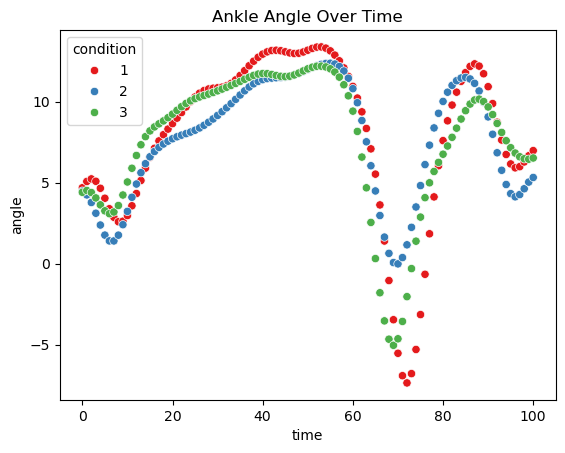

In [84]:
# plot a small subset of the data to see differences in condition
query = "subject == 1 and replication == 1 and joint == 1 and leg == 1"
condition_subset = df.query(query)
plt.title("Ankle Angle Over Time")
sns.scatterplot(data=condition_subset, x="time", y="angle", hue="condition", palette="Set1")

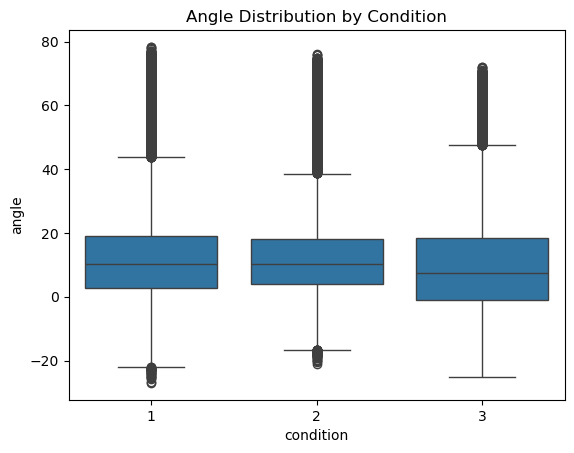

In [85]:
# explore distribution differences by condition
plt.title("Angle Distribution by Condition")
sns.boxplot(data=df, x="condition", y="angle")
plt.show()

When aggregating by condition, there are no significant differences in distribution.

In [86]:
df.groupby("condition").size()

condition
1    60600
2    60600
3    60600
dtype: int64

The dataset is balanced.

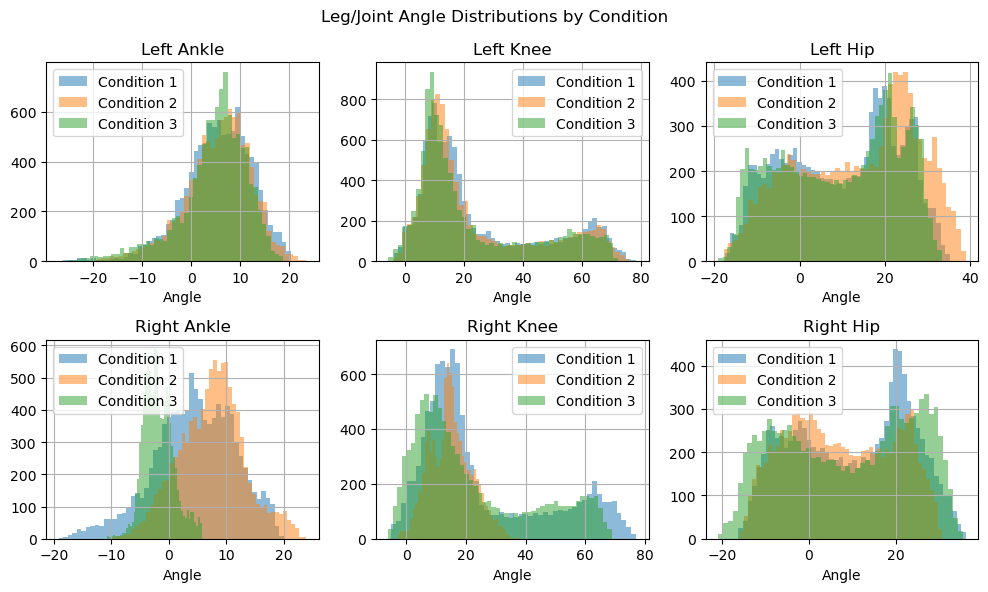

In [115]:
# more rigorous visualization of angle distributions
leg_names = ["Left", "Right"]
joint_names = ["Ankle", "Knee", "Hip"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, leg in enumerate(df["leg"].unique()):
    for j, joint in enumerate(df["joint"].unique()):
        ax = axes[i, j]
        for cond in df["condition"].unique():
            subset = df[(df["leg"] == leg) & (df["joint"] == joint) & (df["condition"] == cond)]
            subset["angle"].hist(bins=50, ax=ax, alpha=0.5, label=f"Condition {cond}")
        ax.set_title(f"{leg_names[i]} {joint_names[j]}")
        ax.set_xlabel("Angle")
        ax.legend()

plt.suptitle("Leg/Joint Angle Distributions by Condition")
plt.tight_layout()
plt.show()

### Different data formats

In [87]:
# long data (given)
df

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
181795,10,3,10,2,3,96,29.778412
181796,10,3,10,2,3,97,29.247559
181797,10,3,10,2,3,98,28.796951
181798,10,3,10,2,3,99,28.432936


In [88]:
# wide data
wide_df = df.pivot_table(index=["subject", "replication", "time", "condition"], columns=["leg", "joint"])
wide_df

angle                                  \
leg                                         1                               2   
joint                                       1         2          3          1   
subject replication time condition                                              
1       1           0    1           4.682881  3.693683  16.607868   5.015829   
                         2           4.474876  3.060746  18.948675   2.743177   
                         3           4.404000  2.352121  16.525506  -3.818095   
                    1    1           5.073127  4.258876  16.851029   5.291201   
                         2           4.243154  3.997421  19.142774   2.156727   
...                                       ...       ...        ...        ...   
10      10          99   2          11.926386  0.106706  32.162279  11.046859   
                         3           7.293149 -3.532651  24.695275  -3.837398   
                    100  1           6.467404  0.519945  27.860387   3.531091   
                         2          11.440937 -0.030581  32.134490  10.671175   
                         3           7.877814 -3.379236  24.901665  -3.823557   

                                                         
leg                                                      
joint                                      2          3  
subject replication time condition                       
1       1           0    1          2.244425  18.948290  
                         2          0.385242  13.986188  
                         3          3.062035  17.055987  
                    1    1          3.381678  19.265300  
                         2          1.035861  13.929114  
...                                      ...        ...  
10      10          99   2          6.104475  24.992667  
                         3         -1.438054  28.432936  
                    100  1         -0.207610  27.477840  
                         2          6.256433  24.763643  
                         3         -1.747282  28.136438  

[30300 rows x 6 columns]

In [89]:
# calculate summary stats for angles
stats = ["mean", "std", "skew", "min", "max"]
wide_df.groupby(["subject", "replication", "condition"]).agg(stats)

angle                                 \
leg                                   1                                  
joint                                 1                                  
                                   mean       std      skew        min   
subject replication condition                                            
1       1           1          7.850984  5.137240 -1.224737  -7.352817   
                    2          7.674093  3.637145 -0.475481  -0.010723   
                    3          7.559693  4.315887 -1.250425  -5.032208   
        2           1          7.003371  5.667427 -1.380600 -10.021197   
                    2          7.532093  4.407946 -0.357874  -2.511839   
...                                 ...       ...       ...        ...   
10      9           2          4.885881  5.929792 -1.244845 -11.577784   
                    3          5.038511  6.015162 -1.135083 -11.294362   
        10          1          6.494675  6.308584 -0.368391  -8.678501   
                    2          4.405595  6.822750 -1.374980 -15.050440   
                    3          3.908324  6.570323 -1.350177 -14.630860   

                                                                          \
leg                                                                        
joint                                             2                        
                                     max       mean        std      skew   
subject replication condition                                              
1       1           1          13.369976  21.860145  18.214232  1.123851   
                    2          12.364694  20.650967  18.107749  1.103360   
                    3          12.184894  22.223086  18.844974  1.006859   
        2           1          13.221472  22.046200  19.048641  1.154176   
                    2          13.410670  21.946555  19.468564  1.202567   
...                                  ...        ...        ...       ...   
10      9           2          12.248372  19.386119  19.457503  0.933291   
                    3          12.680619  18.387504  18.102857  0.932524   
        10          1          18.227833  22.285535  20.986806  0.913712   
                    2          11.926386  19.643638  19.443009  0.980754   
                    3          11.654387  18.891068  18.893064  0.904776   

                                                    ...                        \
leg                                                 ...          2              
joint                                               ...          2              
                                    min        max  ...       mean        std   
subject replication condition                       ...                         
1       1           1          2.200452  62.239251  ...  22.231482  18.466275   
                    2          3.060746  59.962772  ...   9.248877   6.968540   
                    3          2.352121  61.162972  ...  15.539387  18.520295   
        2           1          2.294759  64.317481  ...  24.393793  19.666292   
                    2          0.723223  65.576278  ...   7.731288   5.595920   
...                                 ...        ...  ...        ...        ...   
10      9           2         -2.774656  60.156033  ...  12.449900   4.036028   
                    3         -1.467940  54.774227  ...  15.695331  17.644235   
        10          1          0.142721  64.988960  ...  24.783414  22.722952   
                    2         -2.360035  60.794269  ...  11.238617   3.689577   
                    3         -3.532651  57.374687  ...  15.802689  17.034775   

                                                                         \
leg                                                                       
joint                                                                 3   
                                   skew       min        max       mean   
subject replication condition      

In [90]:
# calculate summary stats for changes in angle (captures temporal differences)
diffs = wide_df.groupby(["subject", "replication", "condition"]).diff().dropna()
diffs.groupby(["subject", "replication", "condition"]).agg(stats)

angle                                \
leg                                   1                                 
joint                                 1                                 
                                   mean       std      skew       min   
subject replication condition                                           
1       1           1          0.022921  0.906193 -0.065065 -2.438277   
                    2          0.008441  0.628100 -0.461646 -1.555748   
                    3          0.021164  0.714794 -0.857405 -2.229414   
        2           1         -0.012108  0.937507  0.110041 -2.383184   
                    2         -0.006681  0.714147 -0.879722 -2.149754   
...                                 ...       ...       ...       ...   
10      9           2         -0.002931  1.030916 -1.472467 -3.141971   
                    3         -0.008204  0.958013 -1.576293 -3.134040   
        10          1         -0.030293  0.976961 -1.717095 -3.191759   
                    2          0.016686  1.152483 -1.144463 -3.454663   
                    3          0.002575  1.030299 -1.276300 -3.190414   

                                                                       \
leg                                                                     
joint                                           2                       
                                    max      mean       std      skew   
subject replication condition                                           
1       1           1          2.498850 -0.014932  1.988638 -0.339753   
                    2          1.320033  0.010894  1.880481 -0.151382   
                    3          1.729613  0.009562  1.816553 -0.513666   
        2           1          2.557865  0.001651  2.008443 -0.392927   
                    2          1.546087 -0.035178  2.147562 -0.501479   
...                                 ...       ...       ...       ...   
10      9           2          1.475070 -0.011830  2.188948 -0.100256   
                    3          1.377498  0.006133  1.868749 -0.180952   
        10          1          1.266819 -0.040176  2.083285 -0.160447   
                    2          1.921190  0.023295  2.171478 -0.309714   
                    3          1.629098 -0.027105  2.025897 -0.271616   

                                                   ...                      \
leg                                                ...         2             
joint                                              ...         2             
                                    min       max  ...      mean       std   
subject replication condition                      ...                       
1       1           1         -4.692793  3.736549  ... -0.001534  1.910775   
                    2         -4.026103  3.732238  ...  0.012382  0.803635   
                    3         -4.113786  3.073017  ... -0.011254  1.847495   
        2           1         -4.588295  3.731640  ...  0.009965  1.983317   
                    2         -5.428038  4.112036  ... -0.019290  0.702536   
...                                 ...       ...  ...       ...       ...   
10      9           2         -4.612259  4.269765  ... -0.004247  0.565033   
                    3         -4.017710  3.783329  ... -0.008331  1.864213   
        10          1         -4.336372  4.001985  ... -0.031620  2.181535   
                    2         -4.980953  4.182374  ... -0.008293  0.526143   
                    3         -4.425971  3.827526  ...  0.014272  1.767895   

                                                                       \
leg                                                                     
joint                                                               3   
                                   skew       min       max      mean   
subject replication condition                                           
1       1           1         -0.318580 -3.999003  3.552112  0.001417   
         

In [92]:
# create a column that stores the quarter for each data point
# quarters -> t = [0..25, 26..50, 51..75, 76..100]
quarter_df = wide_df.copy()
quarter_df["quarter"] = pd.cut(
    quarter_df.index.get_level_values("time"),
    bins=[0, 25, 50, 75, 100],
    labels=["q1", "q2", "q3", "q4"],
    include_lowest=True
    )

# calculate summary stats for each quarter (captures temporal changes in discrete quarters)
quarter_df.groupby(["subject", "replication", "condition", "quarter"]).agg(stats)

/var/folders/k8/3s73cc5x32b13wxlg0_xqlk80000gn/T/ipykernel_1348/1041080302.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quarter_df.groupby(["subject", "replication", "condition", "quarter"]).agg(stats)


angle                       \
leg                                            1                        
joint                                          1                        
                                            mean        std      skew   
subject replication condition quarter                                   
1       1           1         q1        6.020054   2.497216  0.279480   
                              q2       12.103759   1.017150 -0.339023   
                              q3        5.297605   7.875467 -0.494496   
                              q4        8.055755   3.332201 -0.739666   
                    2         q1        5.162191   2.430463 -0.213473   
...                                          ...        ...       ...   
10      10          2         q4        3.445150   7.223360 -0.804608   
                    3         q1        4.642923   3.158199 -0.579616   
                              q2        8.835018   1.134443  0.976287   
                              q3       -0.953993  10.236963  0.010008   
                              q4        3.079962   3.491272 -1.157905   

                                                                        \
leg                                                                      
joint                                                                2   
                                             min        max       mean   
subject replication condition quarter                                    
1       1           1         q1        2.585939  10.285027  14.342747   
                              q2       10.516743  13.167916   9.486646   
                              q3       -7.352817  13.369976  27.025187   
                              q4       -0.653531  12.324473  36.886698   
                    2         q1        1.404310   8.233187  12.942578   
...                                          ...        ...        ...   
10      10          2         q4      -12.092299  11.926386  35.909570   
                    3         q1       -0.833852   7.990667  12.390516   
                              q2        7.675520  11.278678   4.427341   
                              q3      -14.630860  11.654387  29.165886   
                              q4       -5.475749   7.877814  29.840552   

                                                                      \
leg                                                                    
joint                                                                  
                                             std      skew       min   
subject replication condition quarter                                  
1       1           1         q1        4.932424 -1.070176  3.693683   
                              q2        2.771742  0.018573  5.354800   
                              q3       19.037057  0.460581  5.573957   
                              q4       22.431970 -0.361232  2.200452   
                    2         q1        4.382553 -0.843971  3.060746   
...                                          ...       ...       ...   
10      10          2         q4       23.135292 -0.405303 -0.030581   
                    3         q1        6.202099 -0.954134 -0.668735   
                              q2        3.912572  0.385008 -0.085476   
                              q3       20.170532  0.033810  1.609834   
                              q4       22.945661 -0.231721 -3.532651   

                                                  ...                        \
leg                                               ...          2              
joint                                             ...          2              
                                             max  ...       mean        std   
subject replication condition quarter             ...                         
1       1           1         q1       19.146815  ...  13.592810   4.849642   
                              q2       14.488899  ...   8.7678